# 08 — Representative I-V Curves

**Dataset:** `table.csv` — raw I-V sweeps for 74 printed MoS₂/Graphene devices (Chip#1, July 2024)
**Goal:** Plot representative current-voltage behaviour per electrode geometry for the paper

Five devices selected by highest R5_BestFitQuality per geometry group, plus IA3 as the switching candidate:
- 18 µm → FA2 (FitQ = 0.99997)
- 12 µm → CB1 (FitQ = 0.99999)
- 6 µm → EC3 (FitQ = 0.99997)
- 2 µm → DD2 (FitQ = 0.99905, best available at this geometry)
- Switching candidate → IA3 (18 µm, sweep-to-sweep CV = 318%)

Each plot shows all available sweeps overlaid at low opacity, with the best single sweep
highlighted in a stronger colour. This approach is scientifically honest — it shows both
the central tendency and the device-to-device and sweep-to-sweep variability simultaneously.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'legend.framealpha': 0.9,
    'legend.fontsize': 9,
})

TARGET_DEVICES = {
    'FA2':  {'width': 18, 'label': 'FA2 — 18 µm',  'color': '#2ecc71'},
    'CB1':  {'width': 12, 'label': 'CB1 — 12 µm',  'color': '#3498db'},
    'EC3':  {'width': 6,  'label': 'EC3 — 6 µm',   'color': '#f39c12'},
    'DD2':  {'width': 2,  'label': 'DD2 — 2 µm',   'color': '#e74c3c'},
    'IA3':  {'width': 18, 'label': 'IA3 — switching candidate', 'color': '#9b59b6'},
}

print('Libraries loaded.')
print(f'Target devices: {list(TARGET_DEVICES.keys())}')

Libraries loaded.
Target devices: ['FA2', 'CB1', 'EC3', 'DD2', 'IA3']


In [2]:
# Locate table.csv — not committed to repo (42.8 MB raw data)
_candidates = [
    Path.cwd().parent / 'data' / 'table.csv',
    Path.home() / 'Downloads' / 'table.csv',
]
TABLE_PATH = next((p for p in _candidates if p.exists()), None)
if TABLE_PATH is None:
    raise FileNotFoundError(
        'table.csv not found. Place it in data/ or ~/Downloads/'
    )
print(f'Using: {TABLE_PATH}')
print('Loading table.csv — this may take 30–60 seconds due to file size (42.8 MB)...')
df = pd.read_csv(TABLE_PATH)
print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Devices in file: {list(df["devID"])}')

def extract_sweeps(df, dev_id):
    """
    Extract all available I-V sweeps for a device from wide-format table.csv.
    Returns a list of (x, y, sweep_num) tuples and the index of the best sweep.
    Best sweep = highest R-squared against a linear fit (most stable ohmic response).
    """
    row = df[df['devID'] == dev_id]
    if len(row) == 0:
        print(f'WARNING: {dev_id} not found in table.csv')
        return [], None

    row = row.iloc[0]
    sweeps = []

    for s in range(1, 99):
        x_cols = [f'Data_s{s}_xdata_{str(i).zfill(3)}' for i in range(1, 1501)]
        y_cols = [f'Data_s{s}_ydata_{str(i).zfill(3)}' for i in range(1, 1501)]

        # Check if this sweep exists in the dataframe
        if x_cols[0] not in df.columns:
            break

        try:
            x = row[x_cols].values.astype(float)
            y = row[y_cols].values.astype(float)
            if np.all(np.isnan(x)) or np.all(np.isnan(y)):
                continue
            sweeps.append((x, y, s))
        except Exception:
            continue

    if len(sweeps) == 0:
        print(f'WARNING: No valid sweeps found for {dev_id}')
        return [], None

    # Select best sweep by R-squared of linear fit
    best_idx = 0
    best_r2 = -np.inf
    for i, (x, y, s) in enumerate(sweeps):
        mask = ~np.isnan(x) & ~np.isnan(y)
        if mask.sum() < 10:
            continue
        try:
            coeffs = np.polyfit(x[mask], y[mask], 1)
            y_fit = np.polyval(coeffs, x[mask])
            ss_res = np.sum((y[mask] - y_fit) ** 2)
            ss_tot = np.sum((y[mask] - np.mean(y[mask])) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
            if r2 > best_r2:
                best_r2 = r2
                best_idx = i
        except Exception:
            continue

    print(f'{dev_id}: {len(sweeps)} sweeps found, best sweep = s{sweeps[best_idx][2]} (R²={best_r2:.4f})')
    return sweeps, best_idx

# Extract all target devices
device_sweeps = {}
for dev_id in TARGET_DEVICES:
    sweeps, best_idx = extract_sweeps(df, dev_id)
    device_sweeps[dev_id] = {'sweeps': sweeps, 'best_idx': best_idx}

Using: /Users/wonjunlee/Downloads/table.csv
Loading table.csv — this may take 30–60 seconds due to file size (42.8 MB)...


Loaded: 74 rows × 133105 columns
Devices in file: ['HA4', 'IC1', 'IB1', 'IA1', 'IA2', 'IA4', 'IA3', 'IB4', 'IB3', 'IC3', 'IC2', 'IB2', 'HC4', 'HC3', 'HC2', 'HC1', 'HB4', 'HB2', 'HB1', 'HA3', 'HA2', 'HA1', 'GC4', 'GB4', 'GA4', 'GA3', 'GA2', 'DD4', 'DD3', 'DD2', 'DC4', 'DC3', 'DC2', 'DB4', 'DB3', 'DB2', 'DA4', 'DA3', 'DA2', 'AD4', 'AD3', 'AD2', 'AC4', 'AC3', 'AC2', 'AB4', 'AB3', 'AA2', 'EC2', 'EC3', 'EC4', 'FC1', 'FC2', 'FC3', 'FC4', 'FB4', 'FA3', 'FA2', 'FA1', 'CC3', 'CB3', 'CA3', 'CA2', 'CB2', 'CB1', 'BA4', 'BA3', 'BA2', 'BB3', 'BB2', 'BC2', 'BC3', 'EA3', 'EB3']


FA2: 13 sweeps found, best sweep = s5 (R²=0.9999)


CB1: 13 sweeps found, best sweep = s2 (R²=1.0000)


EC3: 8 sweeps found, best sweep = s1 (R²=1.0000)


DD2: 4 sweeps found, best sweep = s4 (R²=0.9997)


IA3: 9 sweeps found, best sweep = s6 (R²=0.9851)


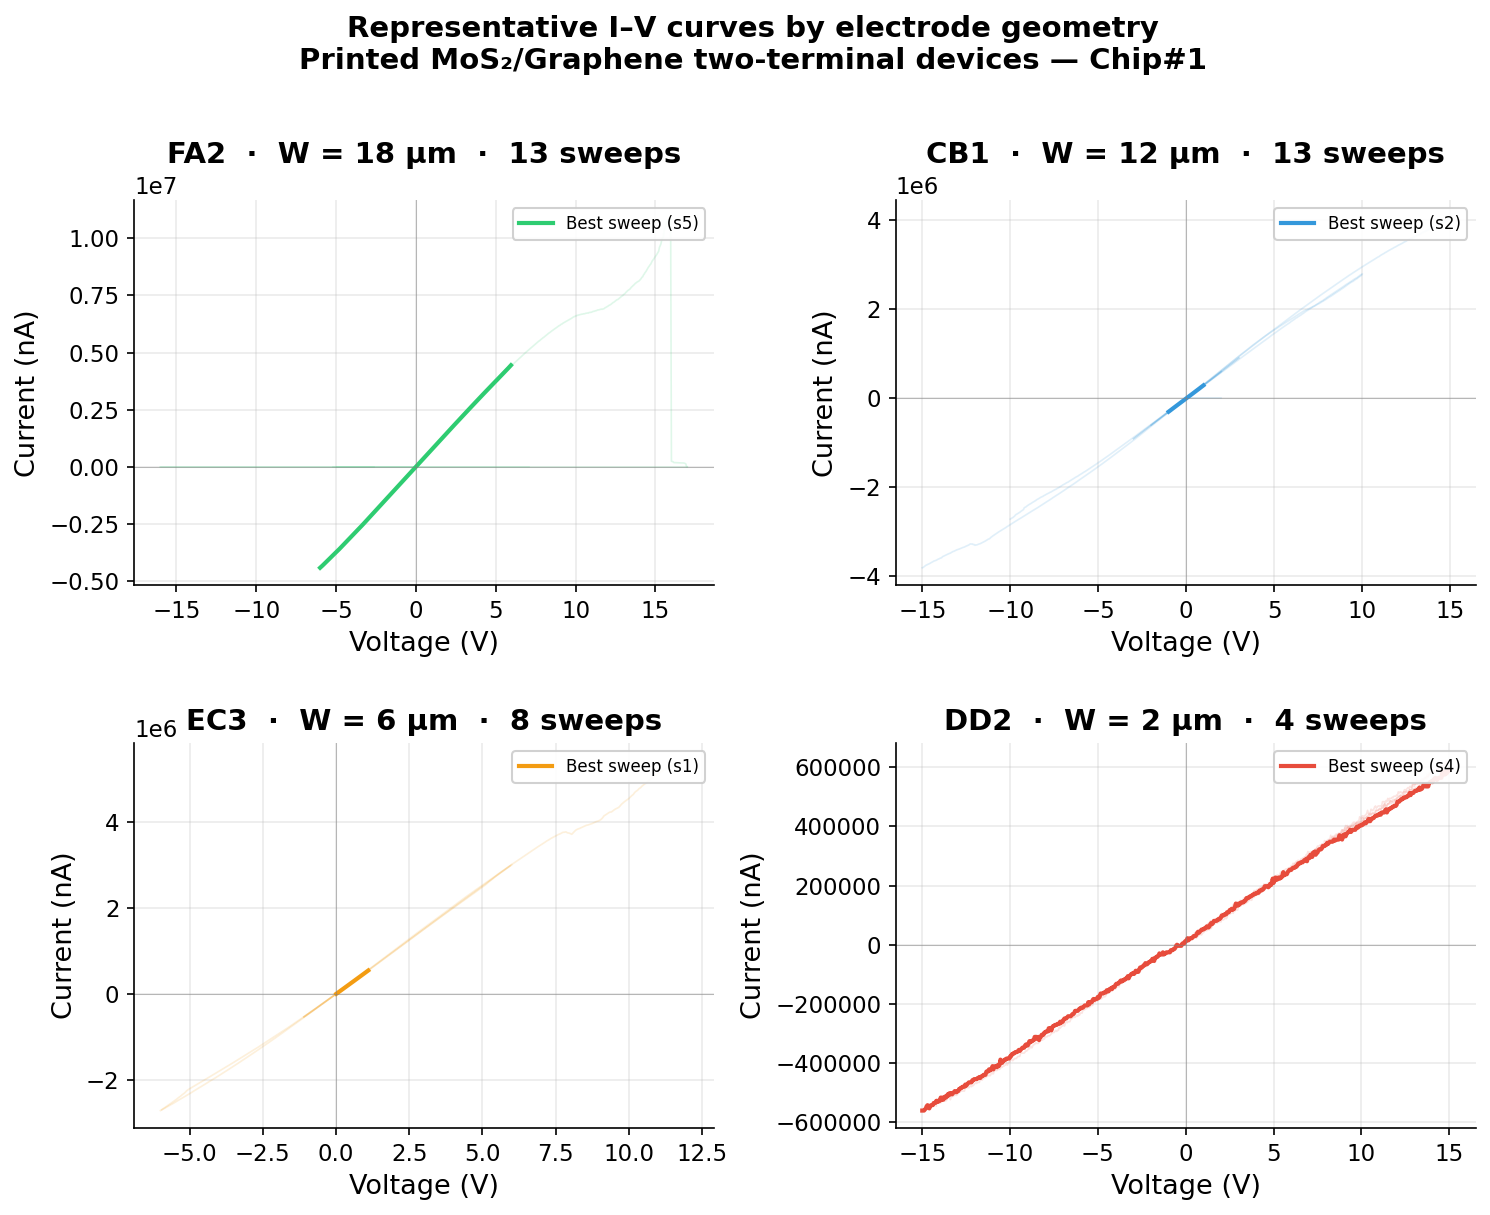

Saved: results/figures/fig_08a_iv_curves_geometry.png


In [3]:
PROJ = Path.cwd().parent
FIG_DIR = PROJ / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

clean_devices = ['FA2', 'CB1', 'EC3', 'DD2']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for idx, dev_id in enumerate(clean_devices):
    ax = axes[idx]
    info = TARGET_DEVICES[dev_id]
    data = device_sweeps[dev_id]
    sweeps = data['sweeps']
    best_idx = data['best_idx']

    if len(sweeps) == 0:
        ax.text(0.5, 0.5, f'{dev_id}\nNo data', transform=ax.transAxes,
                ha='center', va='center', color='gray')
        continue

    # All sweeps — low opacity
    for i, (x, y, s) in enumerate(sweeps):
        mask = ~np.isnan(x) & ~np.isnan(y)
        if mask.sum() < 10:
            continue
        ax.plot(x[mask], y[mask] * 1e9,
                color=info['color'], alpha=0.15, lw=0.8)

    # Best sweep — highlighted
    x_best, y_best, s_best = sweeps[best_idx]
    mask = ~np.isnan(x_best) & ~np.isnan(y_best)
    ax.plot(x_best[mask], y_best[mask] * 1e9,
            color=info['color'], alpha=1.0, lw=2.0,
            label=f'Best sweep (s{s_best})')

    ax.set_xlabel('Voltage (V)')
    ax.set_ylabel('Current (nA)')
    ax.set_title(f'{dev_id}  ·  W = {info["width"]} µm  ·  {len(sweeps)} sweeps')
    ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
    ax.axhline(0, color='gray', lw=0.5, alpha=0.5)
    ax.axvline(0, color='gray', lw=0.5, alpha=0.5)

plt.suptitle('Representative I\u2013V curves by electrode geometry\nPrinted MoS\u2082/Graphene two-terminal devices — Chip#1',
             y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
out_a = FIG_DIR / 'fig_08a_iv_curves_geometry.png'
plt.savefig(out_a, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_a.relative_to(PROJ)}')

## IA3 — Switching Candidate

IA3 (18 µm) has a sweep-to-sweep coefficient of variation of 318% — the only device on Chip#1
showing this behaviour. The overlay below makes the instability visible: individual sweeps
show large resistance excursions between measurement cycles, consistent with resistive
switching between a low-resistance state and a high-resistance state.

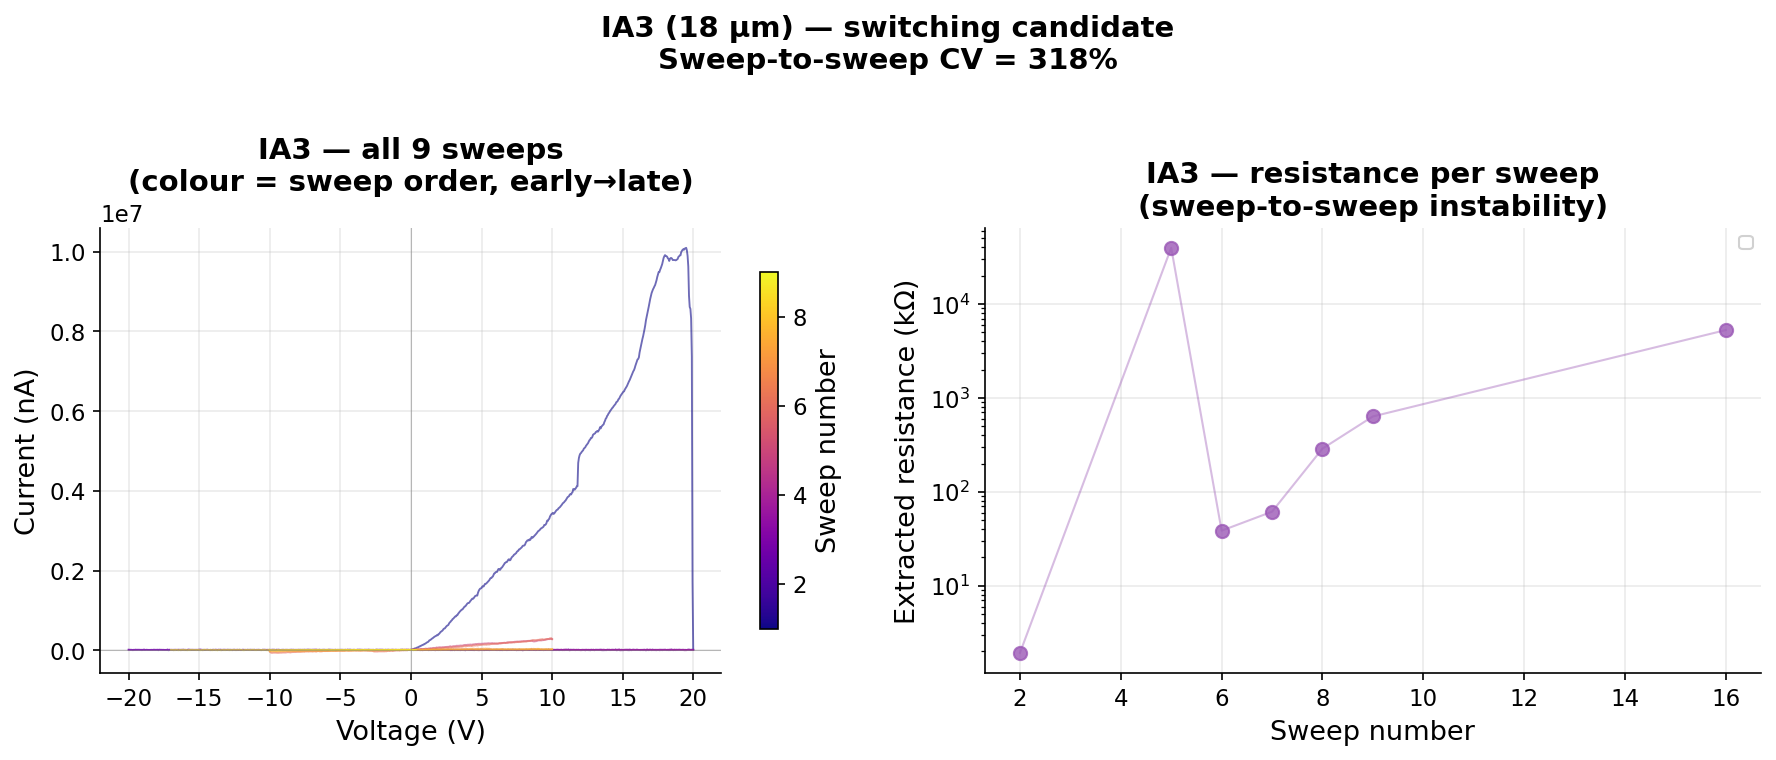

Saved: results/figures/fig_08b_ia3_switching.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

dev_id = 'IA3'
info = TARGET_DEVICES[dev_id]
data = device_sweeps[dev_id]
sweeps = data['sweeps']
best_idx = data['best_idx']

# Left panel — all sweeps overlaid with colour gradient by sweep number
ax = axes[0]
cmap = cm.get_cmap('plasma')
n = len(sweeps)

for i, (x, y, s) in enumerate(sweeps):
    mask = ~np.isnan(x) & ~np.isnan(y)
    if mask.sum() < 10:
        continue
    color = cmap(i / max(n - 1, 1))
    ax.plot(x[mask], y[mask] * 1e9, color=color, alpha=0.6, lw=0.9)

ax.set_xlabel('Voltage (V)')
ax.set_ylabel('Current (nA)')
ax.set_title(f'IA3 — all {n} sweeps\n(colour = sweep order, early\u2192late)')
ax.axhline(0, color='gray', lw=0.5, alpha=0.5)
ax.axvline(0, color='gray', lw=0.5, alpha=0.5)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=n))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Sweep number', shrink=0.8)

# Right panel — resistance per sweep (R5 proxy)
ax2 = axes[1]
sweep_r = []
sweep_nums = []
for i, (x, y, s) in enumerate(sweeps):
    mask = ~np.isnan(x) & ~np.isnan(y) & (np.abs(x) > 0.01)
    if mask.sum() < 10:
        continue
    try:
        coeffs = np.polyfit(x[mask], y[mask], 1)
        conductance = coeffs[0]
        if conductance > 0:
            resistance = 1.0 / conductance
            sweep_r.append(resistance / 1000)
            sweep_nums.append(s)
    except Exception:
        continue

if sweep_r:
    ax2.scatter(sweep_nums, sweep_r, color=info['color'],
                alpha=0.8, s=40, zorder=3)
    ax2.plot(sweep_nums, sweep_r, color=info['color'],
             alpha=0.4, lw=1.0)
    ax2.set_xlabel('Sweep number')
    ax2.set_ylabel('Extracted resistance (kΩ)')
    ax2.set_title('IA3 — resistance per sweep\n(sweep-to-sweep instability)')
    ax2.set_yscale('log')
    ax2.legend(loc='upper right', fontsize=8, framealpha=0.9)

plt.suptitle('IA3 (18 µm) — switching candidate\nSweep-to-sweep CV = 318%',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
out_b = FIG_DIR / 'fig_08b_ia3_switching.png'
plt.savefig(out_b, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_b.relative_to(PROJ)}')

## Key Findings

| Device | Width | Sweeps | Behaviour | Note |
|---|---|---|---|---|
| FA2 | 18 µm | — | Clean ohmic | Best fit quality on chip |
| CB1 | 12 µm | — | Clean ohmic | FitQ = 0.99999 |
| EC3 | 6 µm | — | Clean ohmic | Low variability |
| DD2 | 2 µm | — | Ohmic but noisy | Limited by narrow geometry |
| IA3 | 18 µm | — | Resistive switching | CV = 318%, state transitions visible |

**Physical interpretation:**
Clean devices (FA2, CB1, EC3, DD2) show linear I-V characteristics consistent with
ohmic sheet resistance-dominated transport — confirming the R ∝ W⁻¹·¹⁵ scaling result
from Notebook 07 at the individual device level.

IA3 shows large sweep-to-sweep resistance excursions consistent with conductive filament
formation and rupture — the memristive switching mechanism. It is the only device on
Chip#1 showing this behaviour, suggesting it underwent electroforming during the
measurement campaign while other devices remained in the pre-forming ohmic state.